In [5]:
# Imports
import numpy as np
import scipy.io
from scipy.signal import butter, filtfilt, hilbert, find_peaks
from scipy.ndimage import gaussian_filter1d
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import random
import platform
import os

In [6]:
# Device configuration: (use MPS on Mac if available)
# ======================================================
# Device configuration for parallel processing. 
# ======================================================
if platform.system() == 'Windows' or platform.system() == 'Linux':
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
elif platform.system() == 'Darwin': # MacOS
    device = torch.device('mps' if torch.backends.mps.is_available() else 'cpu')
else:
    device = torch.device('cpu')
print("Using device:", device)

Using device: cpu


In [7]:
# Helper Functions

# For Section 3: Process LFP into EEG bands with flexibility
def bandpass_filter(data, lowcut, highcut, fs, order=3):
    nyq = 0.5 * fs
    low = lowcut / nyq
    high = highcut / nyq
    b, a = butter(order, [low, high], btype='band')
    return filtfilt(b, a, data)

def get_band_envelopes(signal, fs, bands_dict, selected_bands):
    filtered_signals = {}
    for band in selected_bands:
        low, high = bands_dict[band]
        filtered = bandpass_filter(signal, low, high, fs)
        analytic_signal = hilbert(filtered)
        envelope = np.abs(analytic_signal)
        filtered_signals[band] = envelope
    eeg_features = np.column_stack([filtered_signals[band] for band in selected_bands])
    return filtered_signals, eeg_features


# For Section 5: Detect spikes from raw LFP and compute firing rate using Gaussian smoothing
def detect_spikes(lfp, fs, lowcut=100, highcut=300, threshold_multiplier=4, refractory_period=0.002):
    filtered = bandpass_filter(lfp, lowcut, highcut, fs, order=3)
    noise_std = np.median(np.abs(filtered)) / 0.6745
    threshold = threshold_multiplier * noise_std
    min_distance = int(refractory_period * fs)
    spike_indices, _ = find_peaks(filtered, height=threshold, distance=min_distance)
    return spike_indices

# For Section 7: Create sliding windows for the dataset
def create_sliding_windows(features, target, window_size, step_size):
    X, y = [], []
    for start in range(0, len(features) - window_size + 1, step_size):
        end = start + window_size
        X.append(features[start:end])
        y.append(target[start:end])
    return np.array(X), np.array(y)

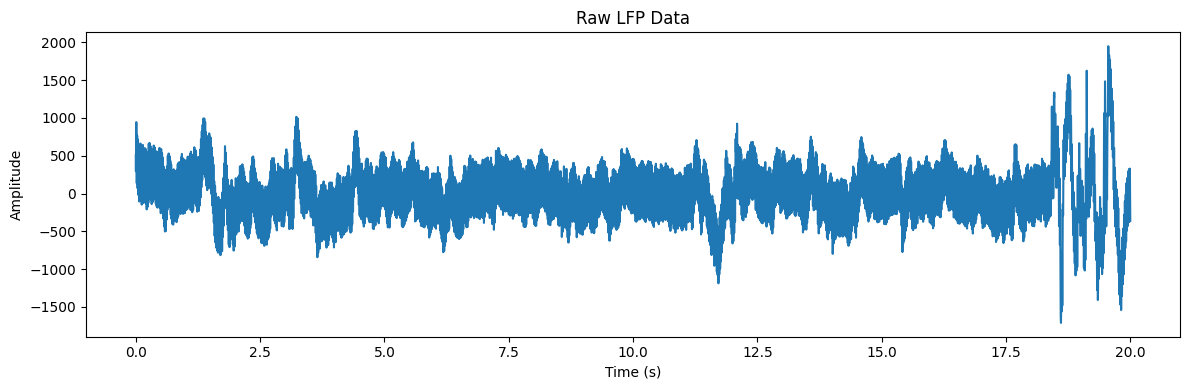

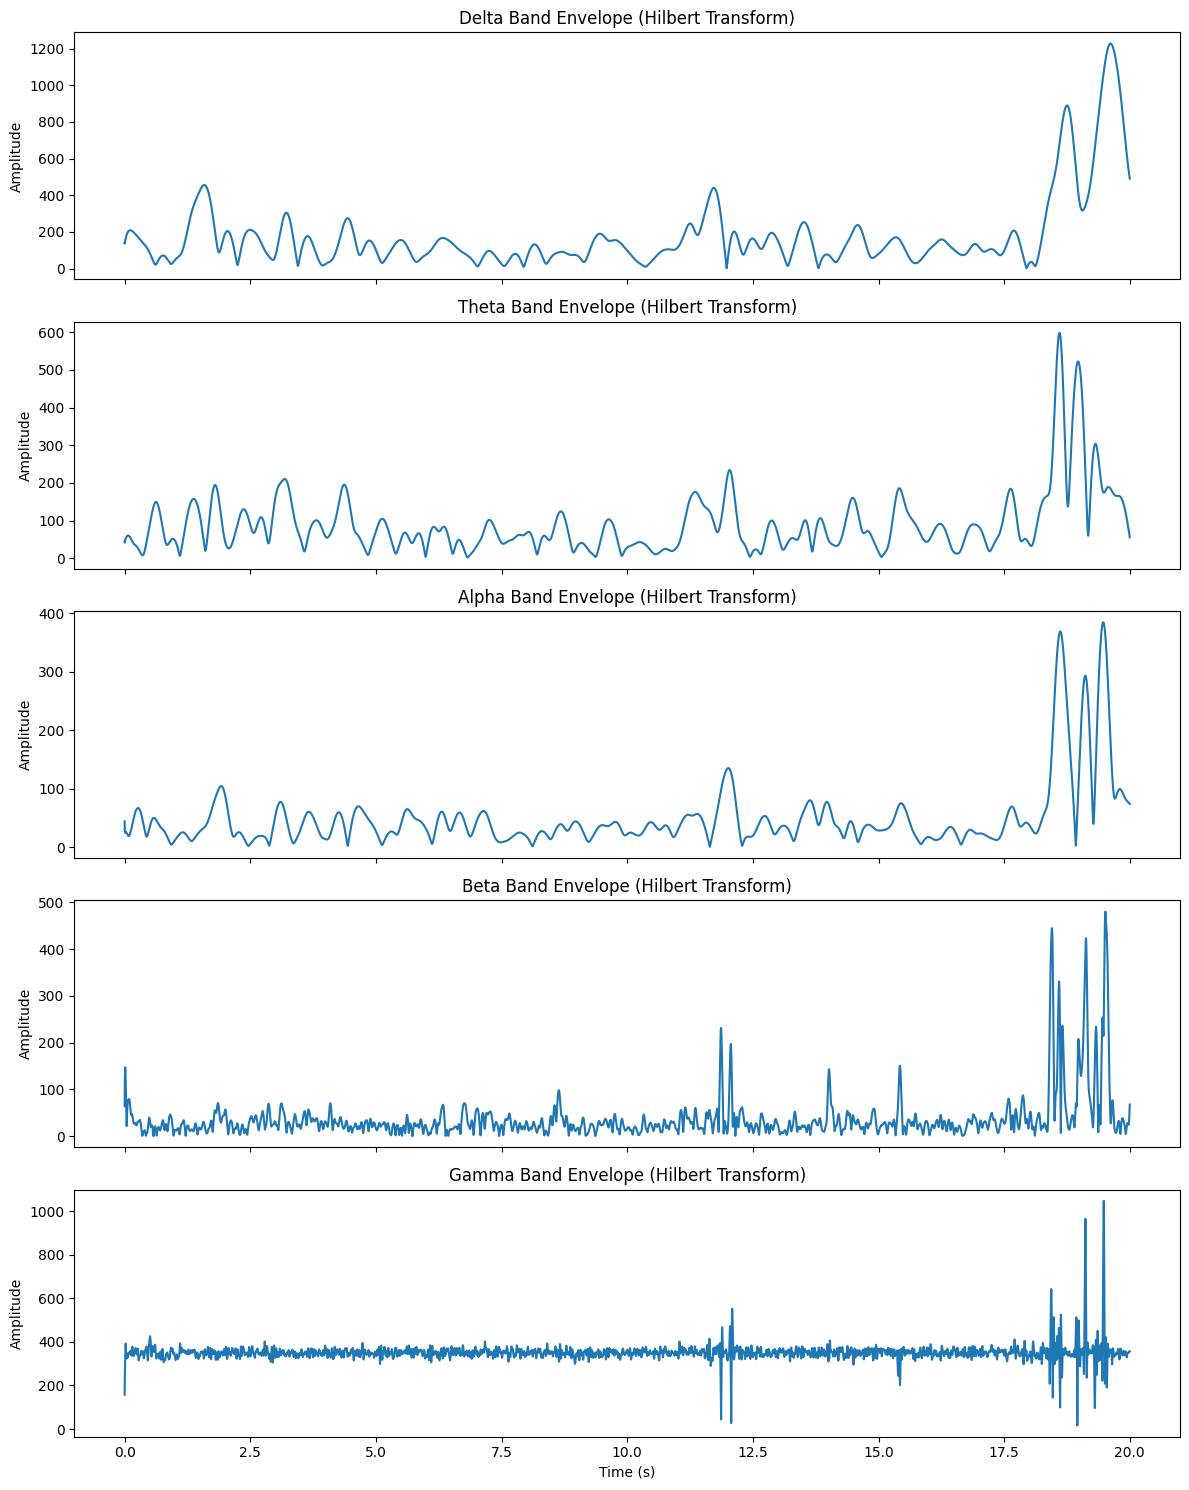

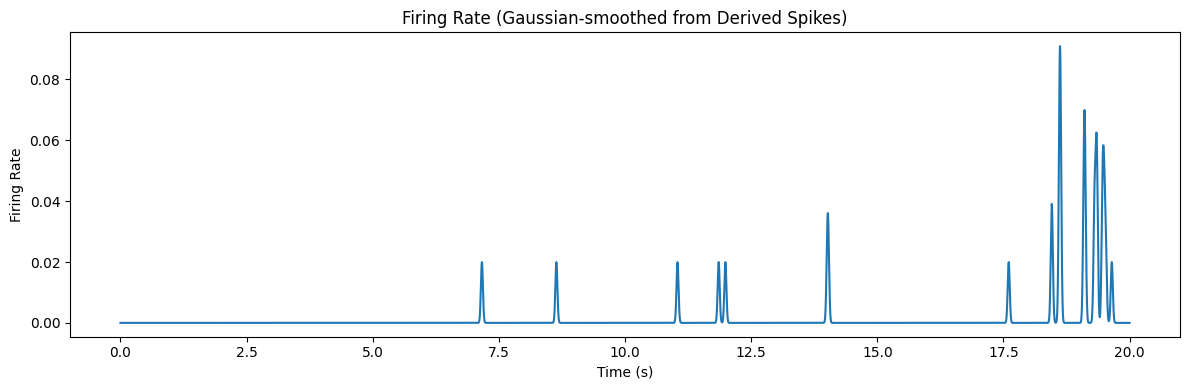

In [8]:
# ===========================================
# 1. Load MATLAB data (only LFP is used now)
# ===========================================
sample_filepath = os.sep.join(['data', 'patients', '202014', 'ns2eeg_202014.mat'])
mat = scipy.io.loadmat(sample_filepath)
microwire = mat['ns2_sEEG'][106, :].squeeze()

# Convert LFP data to float (if originally int16)
microwire = microwire.astype(np.float64)

# Define sampling frequency (Hz)
fs = 1000.0

# ===========================
# 2. Plot raw LFP data (first 20000 samples)
# ===========================
segment = slice(0, 20000)  # first 20000 samples for visualization
time_vec = np.arange(20000) / fs

plt.figure(figsize=(12, 4))
plt.plot(time_vec, microwire[segment])
plt.title("Raw LFP Data")
plt.xlabel("Time (s)")
plt.ylabel("Amplitude")
plt.tight_layout()
plt.show()


# ===========================
# 3. Process LFP into EEG bands with flexibility
# ===========================
all_eeg_bands = {
    'delta': (1, 4),
    'theta': (4, 8),
    'alpha': (8, 12),
    'beta': (12, 30),
    'gamma': (30, 100)
}
selected_bands = ['delta', 'theta', 'alpha', 'beta', 'gamma']

filtered_signals, eeg_features = get_band_envelopes(microwire, fs, all_eeg_bands, selected_bands)

# ===========================
# 4. Plot EEG band envelopes for selected bands
# ===========================

num_bands = len(selected_bands)
fig, axes = plt.subplots(num_bands, 1, figsize=(12, 3 * num_bands), sharex=True)
for idx, band in enumerate(selected_bands):
    signal = filtered_signals[band]
    axes[idx].plot(time_vec, signal[segment])
    axes[idx].set_title(f'{band.capitalize()} Band Envelope (Hilbert Transform)')
    axes[idx].set_ylabel("Amplitude")
axes[-1].set_xlabel("Time (s)")
plt.tight_layout()
plt.show()

# ===========================
# 5. Detect spikes from raw LFP and compute firing rate using Gaussian smoothing
# ===========================

spike_indices = detect_spikes(microwire, fs, lowcut=100, highcut=300, threshold_multiplier=3, refractory_period=0.002)
n_samples = microwire.shape[0]
spike_train = np.zeros(n_samples)
spike_train[spike_indices] = 1
firing_rate = gaussian_filter1d(spike_train, sigma=20)

# ===========================
# 6. Plot the Gaussian-smoothed firing rate (first 20000 samples)
# ===========================
plt.figure(figsize=(12, 4))
plt.plot(time_vec, firing_rate[segment])
plt.title("Firing Rate (Gaussian-smoothed from Derived Spikes)")
plt.xlabel("Time (s)")
plt.ylabel("Firing Rate")
plt.tight_layout()
plt.show()

# ===========================
# 7. Create sliding windows for the dataset
# ===========================
window_size = 2000  # number of time steps per window
step_size = 400     # step size between windows

X, y = create_sliding_windows(eeg_features, firing_rate, window_size, step_size)

# ===========================
# 8. Data Resampling/ Balancing
# ===========================
non_spike_keep_ratio = 0.2  # keep only 20% of windows with low spiking activity
spike_threshold = 0.01      # threshold to consider a window as containing spike activity

indices = np.arange(len(y))
spike_window_indices = indices[np.max(y, axis=1) >= spike_threshold]
null_window_indices = indices[np.max(y, axis=1) < spike_threshold]

if len(null_window_indices) > 0:
    sampled_null_indices = np.random.choice(null_window_indices, 
                                            size=int(len(null_window_indices) * non_spike_keep_ratio),
                                            replace=False)
else:
    sampled_null_indices = np.array([])

balanced_indices = np.concatenate([spike_window_indices, sampled_null_indices]).astype(int)
np.random.shuffle(balanced_indices)

X_balanced = X[balanced_indices]
y_balanced = y[balanced_indices]

# ===========================
# 9. Define custom PyTorch Dataset using the balanced data and split into train/val/test sets
# ===========================
class EEGDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.float32).unsqueeze(-1)
    
    def __len__(self):
        return len(self.X)
    
    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

N = len(X_balanced)
train_end = int(0.7 * N)
val_end = int(0.85 * N)

train_dataset = EEGDataset(X_balanced[:train_end], y_balanced[:train_end])
val_dataset = EEGDataset(X_balanced[train_end:val_end], y_balanced[train_end:val_end])
test_dataset = EEGDataset(X_balanced[val_end:], y_balanced[val_end:])

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=64, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False)

# ===========================
# 10. Define the Channel Attention module and updated 3-layer BiLSTM model with dropout
# ===========================
# Channel Attention module using CBAM-style mechanism
class ChannelAttention(nn.Module):
    def __init__(self, num_channels, reduction=4):
        super(ChannelAttention, self).__init__()
        hidden_channels = max(num_channels // reduction, 1)
        self.mlp = nn.Sequential(
            nn.Linear(num_channels, hidden_channels),
            nn.ReLU(),
            nn.Linear(hidden_channels, num_channels)
        )
        self.sigmoid = nn.Sigmoid()
    
    def forward(self, x):
        # x shape: (batch, seq_len, num_channels)
        # Pool along the time dimension: average and max pooling
        avg_pool = x.mean(dim=1)       # shape: (batch, num_channels)
        max_pool, _ = x.max(dim=1)      # shape: (batch, num_channels)
        avg_out = self.mlp(avg_pool)
        max_out = self.mlp(max_pool)
        # Combine and pass through sigmoid
        attn = self.sigmoid(avg_out + max_out)  # shape: (batch, num_channels)
        # Expand to (batch, seq_len, num_channels) for multiplication
        attn_expanded = attn.unsqueeze(1)
        x_attended = x * attn_expanded
        return x_attended, attn  # returning attn per sample

# Updated model that incorporates the ChannelAttention module
class StackedBiLSTMModel(nn.Module):
    def __init__(self, input_size, dropout=0.0):
        super(StackedBiLSTMModel, self).__init__()
        # Apply channel attention to the raw EEG band inputs
        self.channel_attention = ChannelAttention(num_channels=input_size, reduction=2)
        self.lstm1 = nn.LSTM(input_size=input_size,
                             hidden_size=128,
                             num_layers=1,
                             bidirectional=True,
                             batch_first=True)
        self.dropout1 = nn.Dropout(dropout)
        self.lstm2 = nn.LSTM(input_size=128*2,
                             hidden_size=64,
                             num_layers=1,
                             bidirectional=True,
                             batch_first=True)
        self.dropout2 = nn.Dropout(dropout)
        self.lstm3 = nn.LSTM(input_size=64*2,
                             hidden_size=32,
                             num_layers=1,
                             bidirectional=True,
                             batch_first=True)
        self.dropout3 = nn.Dropout(dropout)
        self.fc = nn.Linear(32*2, 16)
        self.relu = nn.ReLU()
        self.fc2 = nn.Linear(16, 1)
    
    def forward(self, x):
        # x: (batch, seq_len, input_size)
        # Apply channel attention to weight the input EEG bands
        x, attn_weights = self.channel_attention(x)
        out, _ = self.lstm1(x)
        out = self.dropout1(out)
        out, _ = self.lstm2(out)
        out = self.dropout2(out)
        out, _ = self.lstm3(out)
        out = self.dropout3(out)
        out = self.fc(out)
        out = self.relu(out)
        out = self.fc2(out)
        return out, attn_weights

input_size = eeg_features.shape[1]  # number of EEG bands
model = StackedBiLSTMModel(input_size, dropout=0.2).to(device)
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=1e-4)

In [ ]:
# Train and Evaluation

# ===========================
# 11. Training loop with standard MSE loss and loss tracking
# ===========================
num_epochs = 50
train_losses, val_losses = [], []

for epoch in range(num_epochs):
    model.train()
    epoch_train_loss = 0.0
    for batch_X, batch_y in train_loader:
        batch_X = batch_X.to(device)
        batch_y = batch_y.to(device)
        
        optimizer.zero_grad()
        outputs, _ = model(batch_X)  # ignore attention weights for loss calculation
        loss = criterion(outputs, batch_y)
        loss.backward()
        optimizer.step()
        epoch_train_loss += loss.item() * batch_X.size(0)
    epoch_train_loss /= len(train_loader.dataset)
    train_losses.append(epoch_train_loss)
    
    model.eval()
    epoch_val_loss = 0.0
    with torch.no_grad():
        for batch_X, batch_y in val_loader:
            batch_X = batch_X.to(device)
            batch_y = batch_y.to(device)
            outputs, _ = model(batch_X)
            loss = criterion(outputs, batch_y)
            epoch_val_loss += loss.item() * batch_X.size(0)
    epoch_val_loss /= len(val_loader.dataset)
    val_losses.append(epoch_val_loss)
    
    print(f"Epoch {epoch+1}/{num_epochs}: Train Loss {epoch_train_loss:.7f}, Val Loss {epoch_val_loss:.7f}")

plt.figure(figsize=(8, 5))
plt.plot(range(1, num_epochs+1), train_losses, label="Train Loss")
plt.plot(range(1, num_epochs+1), val_losses, label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss (MSE)")
plt.title("Training and Validation Loss")
plt.legend()
plt.tight_layout()
plt.show()

# ===========================
# 12. Evaluate on the test set and calculate percent NMSE (using standard MSE)
# ===========================
model.eval()
test_loss = 0.0
all_preds = []
all_targets = []

with torch.no_grad():
    for batch_X, batch_y in test_loader:
        batch_X = batch_X.to(device)
        batch_y = batch_y.to(device)
        outputs, _ = model(batch_X)
        loss = (outputs - batch_y)**2
        test_loss += loss.mean().item() * batch_X.size(0)
        all_preds.append(outputs.cpu().numpy())
        all_targets.append(batch_y.cpu().numpy())

test_loss /= len(test_loader.dataset)
print(f"Test MSE Loss: {test_loss:.7f}")

all_preds = np.concatenate(all_preds, axis=0)
all_targets = np.concatenate(all_targets, axis=0)

all_preds_flat = all_preds.flatten()
all_targets_flat = all_targets.flatten()

mse_value = np.mean((all_targets_flat - all_preds_flat)**2)
nmse_value = mse_value / np.var(all_targets_flat)
percent_nmse = nmse_value
print(f"NMSE: {percent_nmse:.3f}")

# ===========================
# 13. Extract and plot the attention values over the EEG bands from one test batch
# ===========================
model.eval()
with torch.no_grad():
    for batch_X, _ in test_loader:
         batch_X = batch_X.to(device)
         _, attn_weights = model(batch_X)
         # Use the first test batch only
         break

# attn_weights shape: (batch, num_channels)
# Average the attention weights over the batch for a global view
mean_attn = attn_weights.mean(dim=0).cpu().numpy()
print("Average Channel Attention Weights:", mean_attn)

plt.figure(figsize=(8, 5))
plt.bar(selected_bands, mean_attn)
plt.title("Average Channel (EEG Band) Attention Weights")
plt.xlabel("EEG Band")
plt.ylabel("Attention Weight (0-1)")
plt.tight_layout()
plt.show()


In [2]:
# Save the model weights
model_save_path = "stacked_bilstm_model_weights.pth"
torch.save(model.state_dict(), model_save_path)
print(f"Model weights saved to {model_save_path}")

Model weights saved to stacked_bilstm_model_weights.pth


In [9]:
# Load pre-trained weights
filtered_signals, eeg_features = get_band_envelopes(microwire, fs, all_eeg_bands, selected_bands)
input_size = eeg_features.shape[1]  # number of EEG bands
model = StackedBiLSTMModel(input_size, dropout=0.2).to(device)

# Load the model weights
model_load_path = "stacked_bilstm_model_weights.pth"
model.load_state_dict(torch.load(model_load_path, map_location=device))
model.eval()
print(f"Model weights loaded from {model_load_path}")


Model weights loaded from stacked_bilstm_model_weights.pth


Creating windows: 100%|██████████| 18001/18001 [00:00<00:00, 3602694.39it/s]


Continuous windows shape: (18001, 2000, 5)
Now predicting continuous firing rate...


Predicting: 100%|██████████| 282/282 [07:47<00:00,  1.66s/it]


Predictions shape: (18001, 2000)


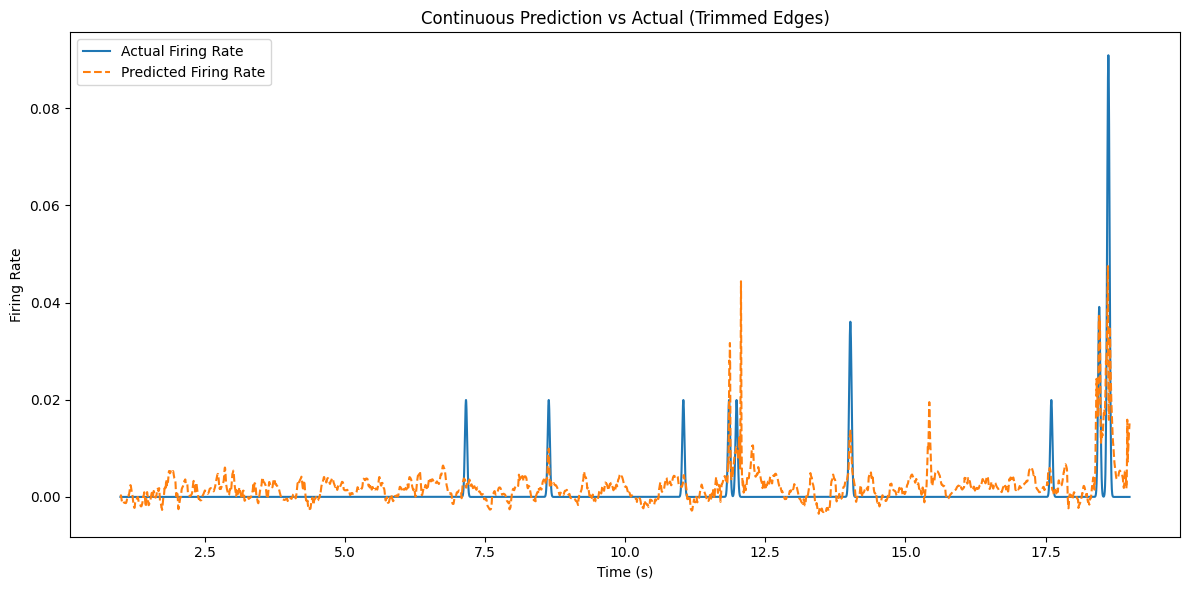

In [ ]:
from torch.utils.data import TensorDataset
from tqdm import tqdm

# ===========================
# 14. Continuous Prediction vs. Actual for first 20000 samples (with trimming)
# ===========================
window_size = 2000
N_cont      = 20000  # first 20000 samples for continuous prediction

# Create overlapping windows (step size 1) from the first N_cont samples
windows = []
for i in tqdm(range(0, N_cont - window_size + 1), desc="Creating windows"):
    windows.append(eeg_features[i:i+window_size])
windows = np.array(windows)
print("Continuous windows shape:", windows.shape)


windows_tensor = torch.tensor(windows, dtype=torch.float32)
cont_dataset = TensorDataset(windows_tensor)
cont_loader = DataLoader(cont_dataset, batch_size=64, shuffle=False)

print("Now predicting continuous firing rate...")

model.eval()
predictions = []
with torch.no_grad():
    for batch_X, in tqdm(cont_loader, desc="Predicting"):
        batch_X = batch_X.to(device)
        batch_pred, _ = model(batch_X)  # ignore attention weights here
        predictions.append(batch_pred.squeeze(-1).cpu().numpy())
predictions = np.concatenate(predictions, axis=0)
print("Predictions shape:", predictions.shape)

# Aggregate overlapping predictions to compute a continuous predicted signal
aggregate_pred = np.zeros(N_cont)
count_pred = np.zeros(N_cont)
num_windows = predictions.shape[0]

for i in range(num_windows):
    aggregate_pred[i:i+window_size] += predictions[i]
    count_pred[i:i+window_size] += 1

continuous_pred = aggregate_pred / count_pred

# Trim the boundaries where count_pred is low (e.g., trim half of the window size)
trim = window_size // 2

plt.figure(figsize=(12, 6))
plt.plot(time_vec[trim:N_cont-trim], firing_rate[trim:N_cont-trim], label="Actual Firing Rate")
plt.plot(time_vec[trim:N_cont-trim], continuous_pred[trim:N_cont-trim], label="Predicted Firing Rate", linestyle="--")
plt.xlabel("Time (s)")
plt.ylabel("Firing Rate")
plt.title("Continuous Prediction vs Actual (Trimmed Edges)")
plt.legend()
plt.tight_layout()
plt.show()

In [30]:
# Create a copy of the predicted firing rate
continuous_pred_thresholded = np.copy(continuous_pred)

# Apply the threshold: set values below 0.009 to 0
continuous_pred_thresholded[continuous_pred_thresholded < 0.008] = 0

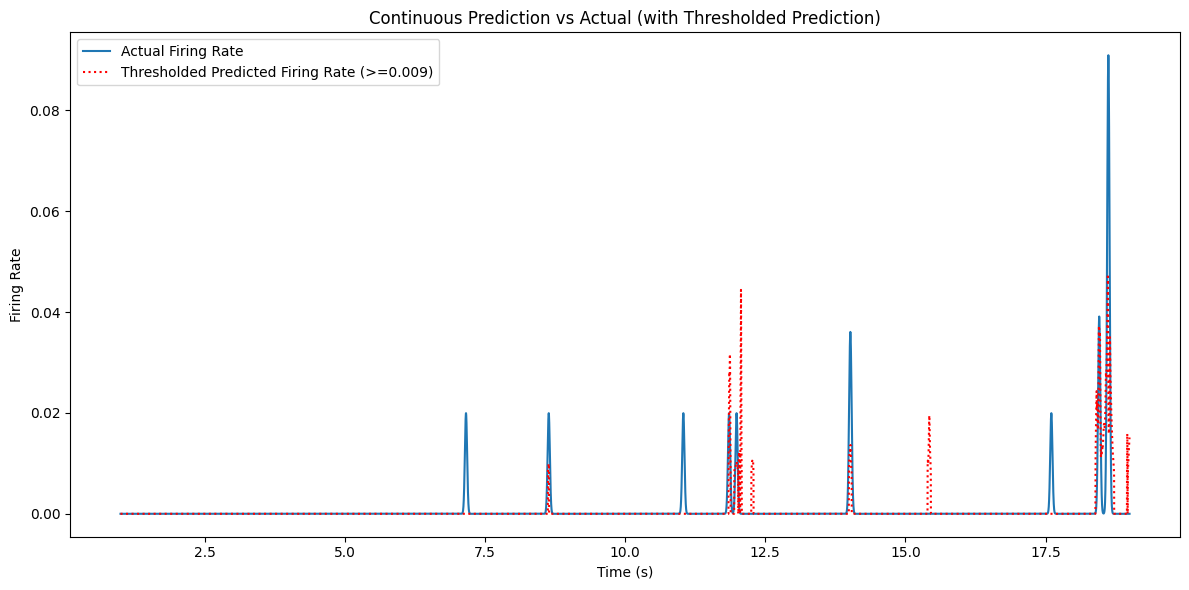

Thresholded predicted firing rate created.


In [31]:
# Optionally, plot the thresholded prediction alongside the original and actual
plt.figure(figsize=(12, 6))
plt.plot(time_vec[trim:N_cont-trim], firing_rate[trim:N_cont-trim], label="Actual Firing Rate")
# plt.plot(time_vec[trim:N_cont-trim], continuous_pred[trim:N_cont-trim], label="Predicted Firing Rate", linestyle="--", alpha=0.7)
plt.plot(time_vec[trim:N_cont-trim], continuous_pred_thresholded[trim:N_cont-trim], label="Thresholded Predicted Firing Rate (>=0.009)", linestyle=":", color='red')
plt.xlabel("Time (s)")
plt.ylabel("Firing Rate")
plt.title("Continuous Prediction vs Actual (with Thresholded Prediction)")
plt.legend()
plt.tight_layout()
plt.show()

print("Thresholded predicted firing rate created.")

Continuous Prediction NMSE (Trimmed): 0.711

Spike Event Detection Performance (Actual >= 0.01, Predicted >= 0.008):
  Total Actual Spike Events: 9
  Total Predicted Spike Events: 11
  Correctly Detected Events (TP): 6
  Missed Events (FN): 3
  False Alarm Events (FP): 6


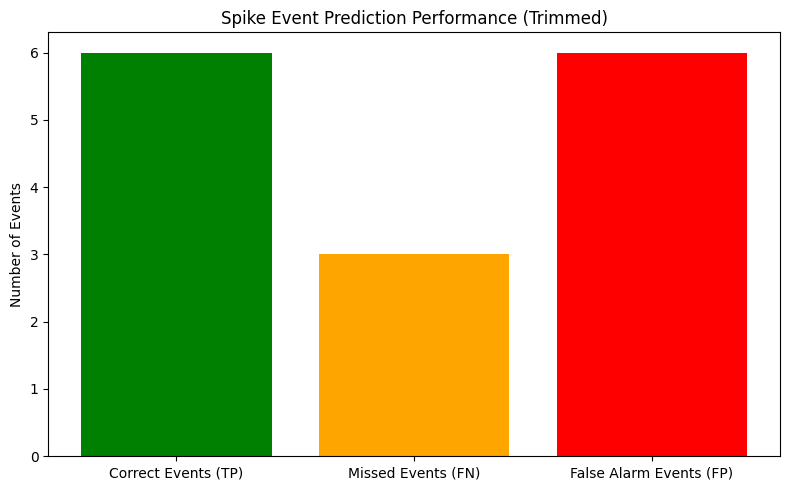

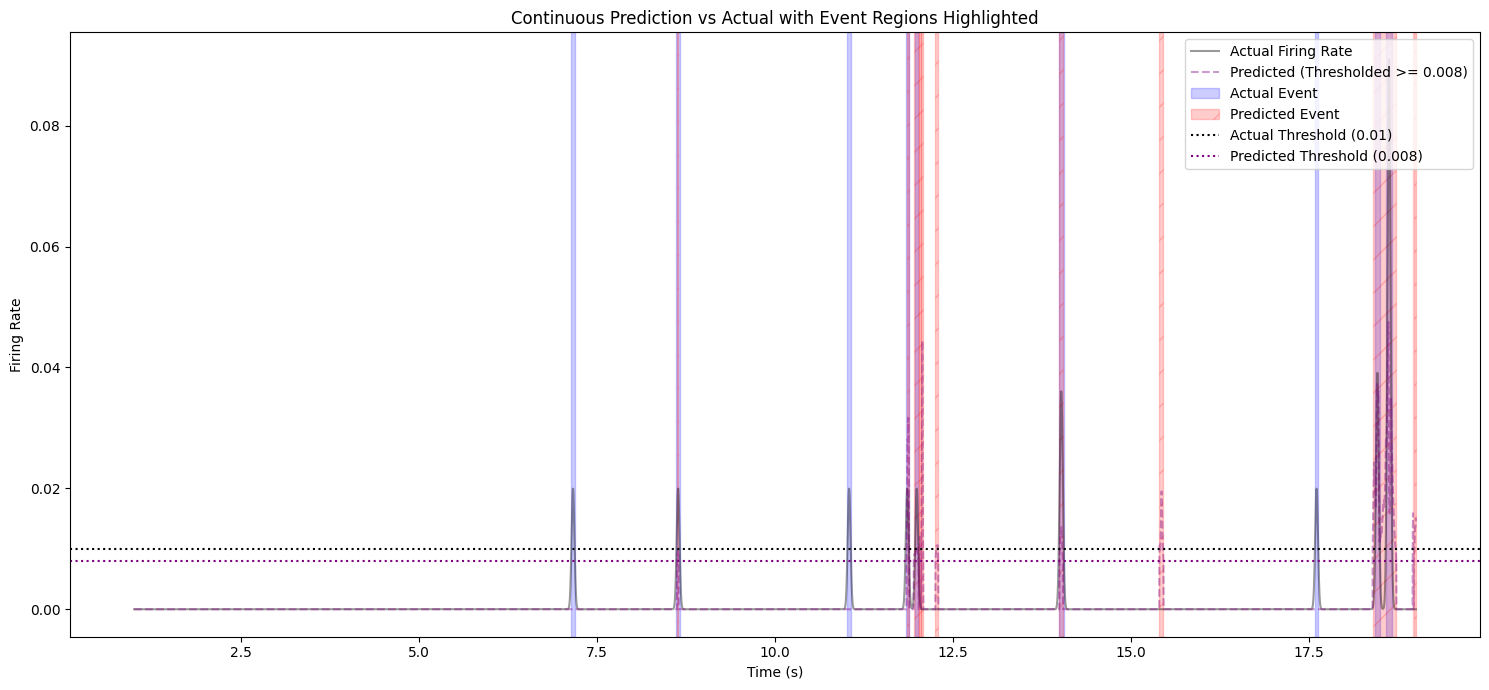

In [35]:
import numpy as np

import matplotlib.pyplot as plt

# ===========================
# 15. Comparison of Predicted vs. Actual Firing Rate (Trimmed) - Event-Based
# ===========================

# Define the valid range after trimming
valid_range = slice(trim, N_cont - trim)
actual_trimmed = firing_rate[valid_range]
predicted_trimmed = continuous_pred[valid_range]
predicted_thresholded_trimmed = continuous_pred_thresholded[valid_range]
time_vec_trimmed = time_vec[valid_range]

# 1. Calculate NMSE for the trimmed continuous prediction (remains the same)
mse_cont = np.mean((actual_trimmed - predicted_trimmed)**2)
nmse_cont = mse_cont / np.var(actual_trimmed)
print(f"Continuous Prediction NMSE (Trimmed): {nmse_cont:.3f}")

# 2. Define spike events based on thresholds
actual_spike_threshold = 0.01 # Use the same threshold as for window selection
predicted_spike_threshold = 0.008 # Threshold used for continuous_pred_thresholded

actual_is_spike = actual_trimmed >= actual_spike_threshold
predicted_is_spike = predicted_thresholded_trimmed > 0 # Equivalent to predicted_trimmed >= predicted_spike_threshold

# Helper function to find regions (start, end indices) where array is True
def find_true_regions(bool_array):
    # Ensure boolean array
    bool_array = np.asarray(bool_array, dtype=bool)
    # Find indices where the value changes
    diff = np.diff(np.concatenate(([False], bool_array, [False])).astype(int))
    starts = np.where(diff == 1)[0]
    ends = np.where(diff == -1)[0] - 1 # end is inclusive
    # Handle cases where starts or ends might be empty
    if len(starts) == 0 or len(ends) == 0:
        return []
    # Ensure starts and ends align correctly
    if starts[0] > ends[0]: # Starts with False, ends with True
        ends = ends[1:]
    if len(starts) > len(ends): # Ends with True
        starts = starts[:len(ends)]
    elif len(ends) > len(starts): # Starts with False
         ends = ends[:len(starts)]

    if len(starts) != len(ends):
         # Fallback or error handling if alignment fails
         print("Warning: Mismatch in start/end region detection.")
         return [] # Or handle differently

    return list(zip(starts, ends))


# 3. Find actual and predicted spike regions (events)
actual_regions = find_true_regions(actual_is_spike)
predicted_regions = find_true_regions(predicted_is_spike)

# 4. Calculate event-based metrics
correct_spike_events = 0 # True Positives (TP events)
matched_predicted_indices = set() # Keep track of predicted regions matched to an actual region

for start_a, end_a in actual_regions:
    found_overlap = False
    for idx_p, (start_p, end_p) in enumerate(predicted_regions):
        # Check for overlap: max(start) <= min(end)
        if max(start_a, start_p) <= min(end_a, end_p):
            found_overlap = True
            matched_predicted_indices.add(idx_p) # Mark this predicted event as matched
            # Break inner loop once an overlap is found for the current actual event
            # (One actual event can be detected by one or more overlapping predicted events)
            break
    if found_overlap:
        correct_spike_events += 1

# False Negatives (FN events): Actual events that did not overlap with any predicted event
false_negative_events = len(actual_regions) - correct_spike_events

# False Positives (FP events): Predicted events that did not overlap with any actual event
false_positive_events = 0
for idx_p, (start_p, end_p) in enumerate(predicted_regions):
    if idx_p not in matched_predicted_indices:
        # Check if this unmatched predicted event overlaps with *any* actual event
        # (This handles cases where a single predicted event might overlap multiple actual events,
        # but we only count it as FP if it overlaps *none*)
        overlaps_any_actual = False
        for start_a, end_a in actual_regions:
             if max(start_a, start_p) <= min(end_a, end_p):
                 overlaps_any_actual = True
                 break
        if not overlaps_any_actual:
             false_positive_events += 1


print(f"\nSpike Event Detection Performance (Actual >= {actual_spike_threshold}, Predicted >= {predicted_spike_threshold}):")
print(f"  Total Actual Spike Events: {len(actual_regions)}")
print(f"  Total Predicted Spike Events: {len(predicted_regions)}")
print(f"  Correctly Detected Events (TP): {correct_spike_events}")
print(f"  Missed Events (FN): {false_negative_events}")
print(f"  False Alarm Events (FP): {false_positive_events}")

# 5. Plot the event-based results
categories_event = ['Correct Events (TP)', 'Missed Events (FN)', 'False Alarm Events (FP)']
counts_event = [correct_spike_events, false_negative_events, false_positive_events]

plt.figure(figsize=(8, 5))
plt.bar(categories_event, counts_event, color=['green', 'orange', 'red'])
plt.ylabel("Number of Events")
plt.title("Spike Event Prediction Performance (Trimmed)")
plt.tight_layout()
plt.show()

# Optional: Plot actual vs predicted with detected regions highlighted (can be slow/cluttered)
plt.figure(figsize=(15, 7))
plt.plot(time_vec_trimmed, actual_trimmed, label='Actual Firing Rate', color='black', alpha=0.4)
plt.plot(time_vec_trimmed, predicted_thresholded_trimmed, label=f'Predicted (Thresholded >= {predicted_spike_threshold})', color='purple', linestyle='--', alpha=0.4)

# # Highlight actual and predicted regions
for start, end in actual_regions:
    plt.axvspan(time_vec_trimmed[start], time_vec_trimmed[end], color='blue', alpha=0.2, label='Actual Event' if start == actual_regions[0][0] else "")
for start, end in predicted_regions:
     plt.axvspan(time_vec_trimmed[start], time_vec_trimmed[end], color='red', alpha=0.2, hatch='/', label='Predicted Event' if start == predicted_regions[0][0] else "")


plt.axhline(actual_spike_threshold, color='black', linestyle=':', label=f'Actual Threshold ({actual_spike_threshold})')
plt.axhline(predicted_spike_threshold, color='purple', linestyle=':', label=f'Predicted Threshold ({predicted_spike_threshold})')

plt.xlabel("Time (s)")
plt.ylabel("Firing Rate")
plt.title("Continuous Prediction vs Actual with Event Regions Highlighted")
# # Avoid duplicate labels in legend
handles, labels = plt.gca().get_legend_handles_labels()
by_label = dict(zip(labels, handles))
plt.legend(by_label.values(), by_label.keys(), loc='upper right')
plt.tight_layout()
plt.show()

Pivoted Data:
Region   Hippocampus       OFC
Subject                       
202014      1.265625  0.777625
202016      2.283375  1.076500
202202      1.832500  1.219875

Paired t-test results:
 t-statistic = 3.468, p-value = 0.074


<Figure size 800x600 with 0 Axes>

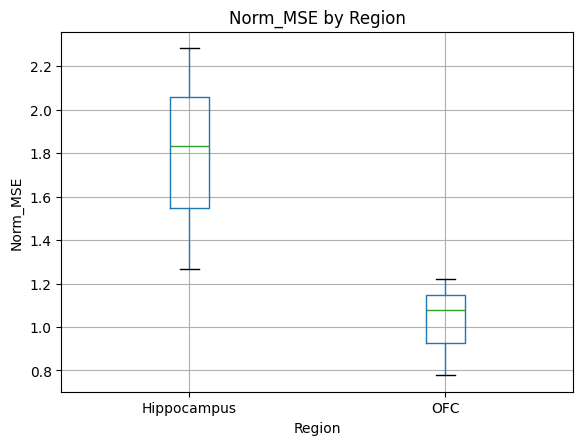

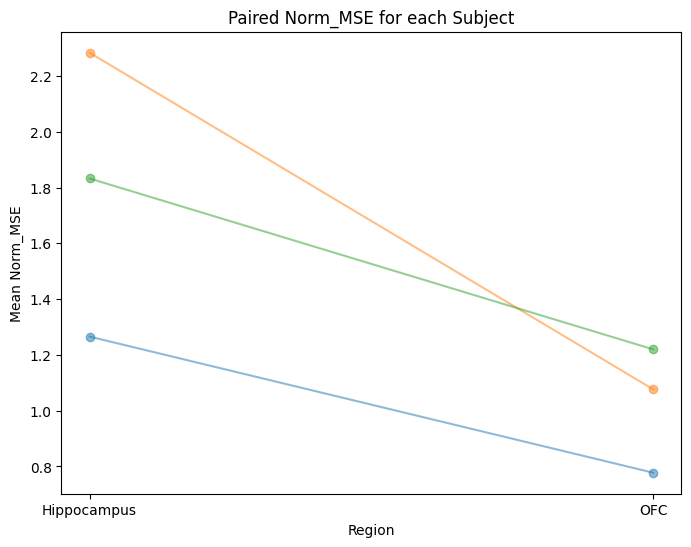

In [5]:

import pandas as pd
import numpy as np
from scipy.stats import ttest_rel
import matplotlib.pyplot as plt

# Load the dataset
sEEG_combined_results_filepath = os.sep.join(['data', 'results', 'seeg_results.csv'])
df = pd.read_csv(sEEG_combined_results_filepath)

# Calculate the average Norm_MSE for each subject and region
df_avg = df.groupby(['Subject', 'Region'])['Norm_MSE'].mean().reset_index()

# Pivot the data to have one column per region for easier paired t-test
df_pivot = df_avg.pivot(index='Subject', columns='Region', values='Norm_MSE')
print("Pivoted Data:")
print(df_pivot.head())

# Perform paired t-test between Hippocampus and OFC
t_stat, p_val = ttest_rel(df_pivot['Hippocampus'], df_pivot['OFC'])
print(f"\nPaired t-test results:\n t-statistic = {t_stat:.3f}, p-value = {p_val:.3f}")

# Visualization: Box plot
plt.figure(figsize=(8, 6))
df_avg.boxplot(column='Norm_MSE', by='Region')
plt.title('Norm_MSE by Region')
plt.suptitle('')
plt.xlabel('Region')
plt.ylabel('Norm_MSE')
plt.show()

# Visualization: Paired Dot Plot with connecting lines for each subject
plt.figure(figsize=(8, 6))
for i, subject in enumerate(df_pivot.index):
    plt.plot(['Hippocampus', 'OFC'], df_pivot.loc[subject], marker='o', linestyle='-', alpha=0.5)
plt.title('Paired Norm_MSE for each Subject')
plt.xlabel('Region')
plt.ylabel('Mean Norm_MSE')
plt.show()



In [7]:
import pandas as pd
import statsmodels.formula.api as smf

# Load the dataset
sEEG_combined_results_filepath = os.sep.join(['data', 'results', 'seeg_results.csv'])
df = pd.read_csv(sEEG_combined_results_filepath)

# Fit a linear mixed-effects model
model = smf.mixedlm("Norm_MSE ~ Region", df, groups=df["Subject"])
result = model.fit()
print(result.summary())


         Mixed Linear Model Regression Results
Model:              MixedLM Dependent Variable: Norm_MSE
No. Observations:   48      Method:             REML    
No. Groups:         3       Scale:              0.3552  
Min. group size:    16      Log-Likelihood:     -46.3203
Max. group size:    16      Converged:          Yes     
Mean group size:    16.0                                
--------------------------------------------------------
              Coef.  Std.Err.   z    P>|z| [0.025 0.975]
--------------------------------------------------------
Intercept      1.794    0.217  8.280 0.000  1.369  2.218
Region[T.OFC] -0.769    0.172 -4.470 0.000 -1.106 -0.432
Group Var      0.096    0.203                           



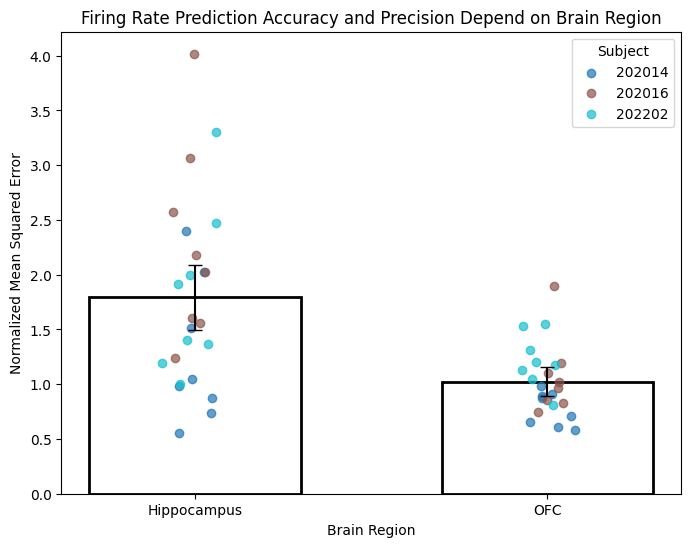

In [8]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Load the dataset
sEEG_combined_results_filepath = os.sep.join(['data', 'results', 'seeg_results.csv'])
df = pd.read_csv(sEEG_combined_results_filepath)

# First, compute subject-level means for each region
df_avg = df.groupby(['Subject', 'Region'])['Norm_MSE'].mean().reset_index()

# Compute summary statistics (mean, std, count) across subjects for each region
region_summary = df_avg.groupby('Region')['Norm_MSE'].agg(['mean', 'std', 'count']).reset_index()
region_summary['sem'] = region_summary['std'] / np.sqrt(region_summary['count'])

# Define regions in a consistent order and their x-axis positions
regions = sorted(df_avg['Region'].unique())
x_positions = np.arange(len(regions))

plt.figure(figsize=(8, 6))

# Plot outlined bars with error bars (using subject-level means)
for i, region in enumerate(regions):
    # Get summary data for this region
    summary = region_summary[region_summary['Region'] == region].iloc[0]
    mean_val = summary['mean']
    sem_val = summary['sem']
    
    # Draw an outlined bar (no fill)
    plt.bar(i, mean_val, width=0.6, color='none', edgecolor='black', linewidth=2)
    # Add error bars
    plt.errorbar(i, mean_val, yerr=sem_val, color='black', capsize=5)

plt.xticks(x_positions, regions)
plt.xlabel('Brain Region')
plt.ylabel('Normalized Mean Squared Error')
plt.title('Firing Rate Prediction Accuracy and Precision Depend on Brain Region')

# Assign a unique color for each subject using a colormap
subjects = sorted(df_avg['Subject'].unique())
colors = plt.cm.tab10(np.linspace(0, 1, len(subjects)))
color_dict = dict(zip(subjects, colors))

# Overlay individual data points colored by Subject
for i, region in enumerate(regions):
    region_data = df[df['Region'] == region]
    for subj in subjects:
        subj_data = region_data[region_data['Subject'] == subj]['Norm_MSE']
        # Apply a small jitter in x-axis
        x_positions = np.random.normal(i, 0.04, size=len(subj_data))
        plt.scatter(x_positions, subj_data, color=color_dict[subj], 
                    label=subj if i == 0 else "", alpha=0.7)


# Create a legend (labels added only once per subject)
plt.legend(title='Subject')
plt.show()


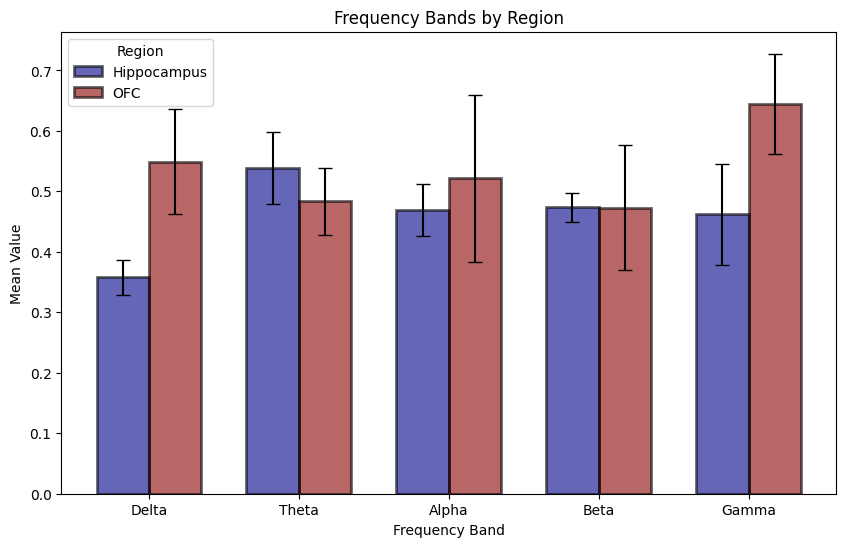

In [9]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Load the dataset
sEEG_combined_results_filepath = os.sep.join(['data', 'results', 'seeg_results.csv'])
df = pd.read_csv(sEEG_combined_results_filepath)

# Define the frequency band columns
freq_vars = ['Delta', 'Theta', 'Alpha', 'Beta', 'Gamma']

# Compute subject-level averages for each frequency band per region
df_avg = df.groupby(['Subject', 'Region'])[freq_vars].mean().reset_index()

# Compute summary statistics (mean and std) for each frequency band per region
region_summary = df_avg.groupby('Region')[freq_vars].agg(['mean', 'std'])
# Flatten the multi-level columns
region_summary.columns = ['_'.join(col) for col in region_summary.columns]
region_summary = region_summary.reset_index()

# Calculate the number of subjects per region to compute standard error (SEM)
subject_counts = df_avg.groupby('Region')['Subject'].nunique()

# For each frequency variable, calculate SEM = std / sqrt(n)
for region in region_summary['Region']:
    n = subject_counts[region]
    for var in freq_vars:
        region_summary.loc[region_summary['Region'] == region, var + '_sem'] = (
            region_summary.loc[region_summary['Region'] == region, var + '_std'] / np.sqrt(n)
        )

# Define region-specific colors: dark blue for Hippocampus, dark red for OFC
color_dict = {'Hippocampus': '#00008B', 'OFC': '#8B0000'}

# Prepare for grouped bar plot
regions = region_summary['Region'].unique()
n_regions = len(regions)
x = np.arange(len(freq_vars))  # one position per frequency band
bar_width = 0.35  # width for each bar
# Calculate offsets for each region's bar in a group (centering them)
offsets = np.linspace(-bar_width/2, bar_width/2, n_regions)

plt.figure(figsize=(10, 6))
for i, region in enumerate(regions):
    # Extract the mean and SEM for the current region for all frequency bands
    region_data = region_summary[region_summary['Region'] == region]
    means = [region_data[var + '_mean'].values[0] for var in freq_vars]
    sems = [region_data[var + '_sem'].values[0] for var in freq_vars]
    
    # Plot bars for this region with error bars and specified outline color (no fill)
    plt.bar(x + offsets[i], means, width=bar_width, color=color_dict[region], edgecolor="black", 
            linewidth=2, yerr=sems, capsize=5, label=region, alpha=0.6)

plt.xticks(x, freq_vars)
plt.xlabel('Frequency Band')
plt.ylabel('Mean Value')
plt.title('Frequency Bands by Region')
plt.legend(title='Region')
plt.show()



In [10]:
import pandas as pd
import statsmodels.formula.api as smf

# Load the dataset
sEEG_combined_results_filepath = os.sep.join(['data', 'results', 'seeg_results.csv'])
df = pd.read_csv(sEEG_combined_results_filepath)

# List of frequency bands
freq_vars = ['Delta', 'Theta', 'Alpha', 'Beta', 'Gamma']

# Dictionary to hold model results for each frequency band
results = {}

# Loop over each frequency band and fit a mixed-effects model
for var in freq_vars:
    # Fit the model: the formula tests if the frequency band varies by Region
    model = smf.mixedlm(f"{var} ~ Region", df, groups=df["Subject"])
    result = model.fit()
    results[var] = result
    print(f"\nResults for {var}:")
    print(result.summary())


c:\Users\PRISM\Documents\CourseSoftware\SpikeInference\.venv\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
c:\Users\PRISM\Documents\CourseSoftware\SpikeInference\.venv\Lib\site-packages\statsmodels\regression\mixed_linear_model.py:2200: ConvergenceWarning: Retrying MixedLM optimization with lbfgs
  warnings.warn(
c:\Users\PRISM\Documents\CourseSoftware\SpikeInference\.venv\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
c:\Users\PRISM\Documents\CourseSoftware\SpikeInference\.venv\Lib\site-packages\statsmodels\regression\mixed_linear_model.py:2200: ConvergenceWarning: Retrying MixedLM optimization with cg
  warnings.warn(
c:\Users\PRISM\Documents\CourseSoftware\SpikeInference\.venv\Lib\


Results for Delta:
        Mixed Linear Model Regression Results
Model:            MixedLM Dependent Variable: Delta   
No. Observations: 48      Method:             REML    
No. Groups:       3       Scale:              0.1428  
Min. group size:  16      Log-Likelihood:     -23.7142
Max. group size:  16      Converged:          No      
Mean group size:  16.0                                
------------------------------------------------------
              Coef. Std.Err.   z   P>|z| [0.025 0.975]
------------------------------------------------------
Intercept     0.358    0.078 4.606 0.000  0.206  0.510
Region[T.OFC] 0.191    0.109 1.750 0.080 -0.023  0.405
Group Var     0.000    0.025                          


Results for Theta:
         Mixed Linear Model Regression Results
Model:              MixedLM Dependent Variable: Theta   
No. Observations:   48      Method:             REML    
No. Groups:         3       Scale:              0.1388  
Min. group size:    16      Log-Lik

c:\Users\PRISM\Documents\CourseSoftware\SpikeInference\.venv\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
c:\Users\PRISM\Documents\CourseSoftware\SpikeInference\.venv\Lib\site-packages\statsmodels\regression\mixed_linear_model.py:2200: ConvergenceWarning: Retrying MixedLM optimization with lbfgs
  warnings.warn(
c:\Users\PRISM\Documents\CourseSoftware\SpikeInference\.venv\Lib\site-packages\statsmodels\regression\mixed_linear_model.py:2237: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)
c:\Users\PRISM\Documents\CourseSoftware\SpikeInference\.venv\Lib\site-packages\statsmodels\regression\mixed_linear_model.py:1634: UserWarning: Random effects covariance is singular
  warnings.warn(msg)
c:\Users\PRISM\Documents\CourseSoftware\SpikeInference\.venv\Lib\site-packages\stat